Ejercicio 1:  
Utilizando siempre N = 1000 muestras. Se pide:

Sintetizar:

Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
Misma señal con 2 W de potencia media y desfasada en π/2.
Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 
Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).
Para cada señal visualice el módulo de la transformada de Fourier.


Bonus:
🤯 Implementar alguna otra señal disponible en scipy.signal.
💎 Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import math

from scipy import signal

Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

Dado que un periodo completo dura 1/f0 y tomo muestra en 1/fs entonces la cantidad de puntos por periodo es (1/f0)/(1/fs). Dado que la frecuencia de la señal es fija lo que modifico es la frecuencia de muestreo para obtener 10 puntos por periodo. Entonces fs=10*fo

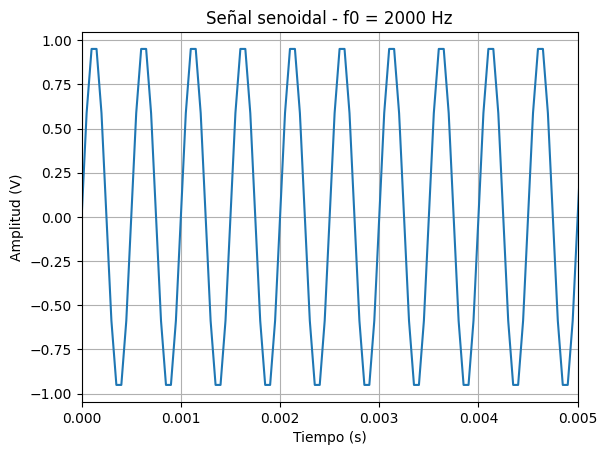

In [2]:
def mi_funcion_sen(vmax = 1, dc = 0, f0 = 2000, n = 1000, fs = 20000, ph=0):
    
    ts = 1 / fs
    
    tt = np.linspace (0, (n-1) * ts , n)
    
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx=mi_funcion_sen()

plt.figure()

plt.title('Señal senoidal - f0 = 2000 Hz')

plt.xlim(0, 0.005) ## Muestro solo los primeros 5ms (10 ciclos). Esto debido a que si no queda como un bloque celeste y no se logra diferenciar la senoidal. 

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.plot(tt, xx)

#Misma señal con 2 W de potencia media y desfasada en π/2.

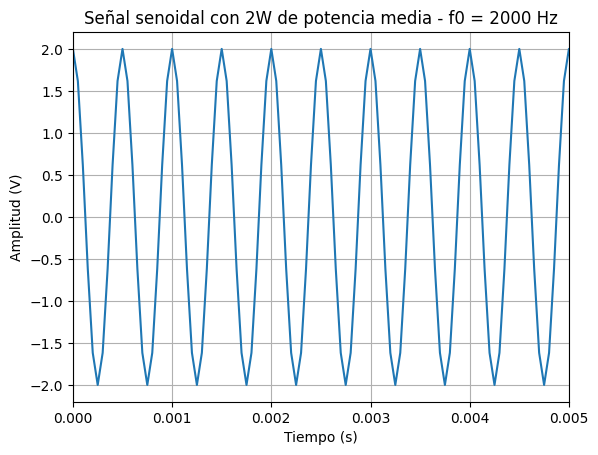

In [3]:
tt2, xx2 = mi_funcion_sen(vmax=2, f0=2000, n=1000, fs=20000, ph=np.pi/2)

plt.figure()

plt.title('Señal senoidal con 2W de potencia media - f0 = 2000 Hz')

plt.xlim(0, 0.005) ## Muestro solo los primeros 5ms (10 ciclos). Esto debido a que si no queda como un bloque celeste y no se logra diferenciar la senoidal. 

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.plot(tt2, xx2)

Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.

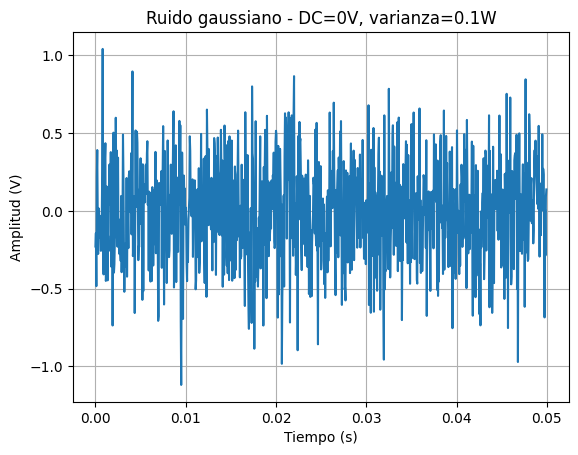

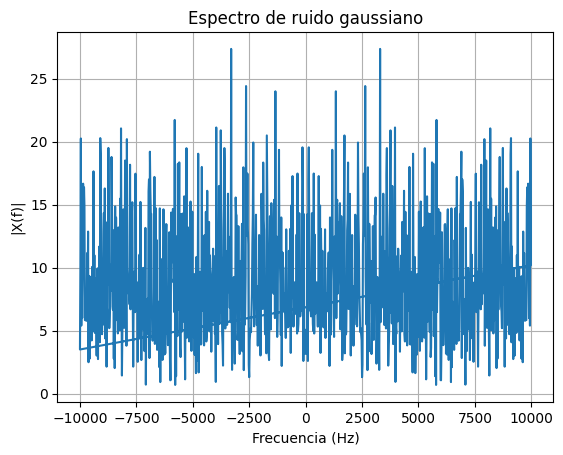

In [6]:
fs = 20000
n = 1000
ts = 1/fs
tt3 = np.linspace(0, (n-1)*ts, n)

varianza = 0.1
dc = 0
sigma = np.sqrt(varianza)  # np.random.normal pide desvío estándar, no varianza

xx3 = dc + sigma * np.random.normal(0, 1, n)  # equivalente a np.random.normal(dc, sigma, n)

plt.figure()
plt.title('Ruido gaussiano - DC=0V, varianza=0.1W')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt3, xx3)

XX3 = np.fft.fft(xx3)
ff3 = np.fft.fftfreq(n, d=ts)

plt.figure()
plt.title('Espectro de ruido gaussiano')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.plot(ff3, np.abs(XX3))

Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 

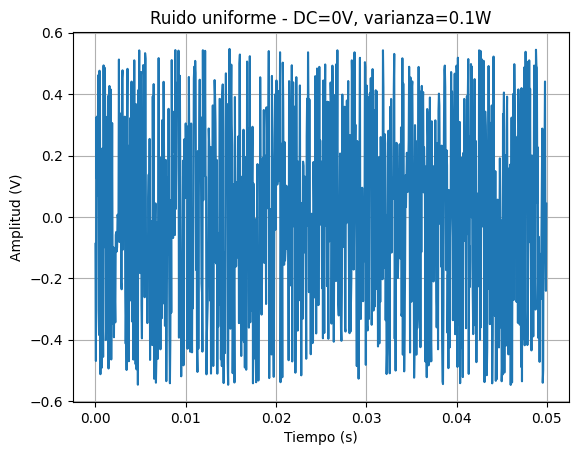

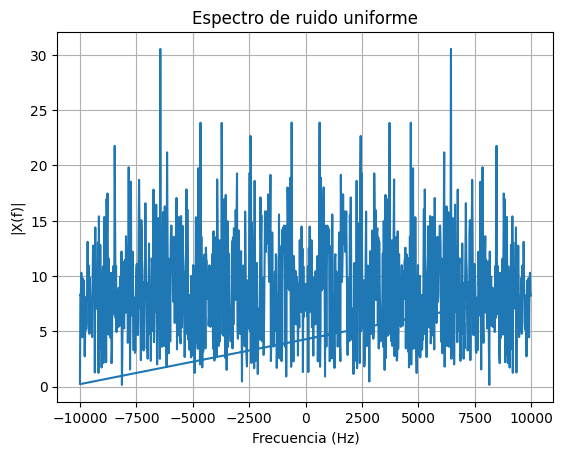

In [8]:
varianza = 0.1
dc = 0
A = np.sqrt(3 * varianza)  # despejado de sigma^2 = A^2/3 (uniforme simétrica en [-A,A])

xx4 = dc + np.random.uniform(-A, A, n)

plt.figure()
plt.title('Ruido uniforme - DC=0V, varianza=0.1W')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt3, xx4)  # reutilizo tt3 porque la base temporal es la misma (fs=20000, n=1000

XX4 = np.fft.fft(xx4)
ff4 = np.fft.fftfreq(n, d=ts)

plt.figure()
plt.title('Espectro de ruido uniforme')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.plot(ff4, np.abs(XX4))

Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).

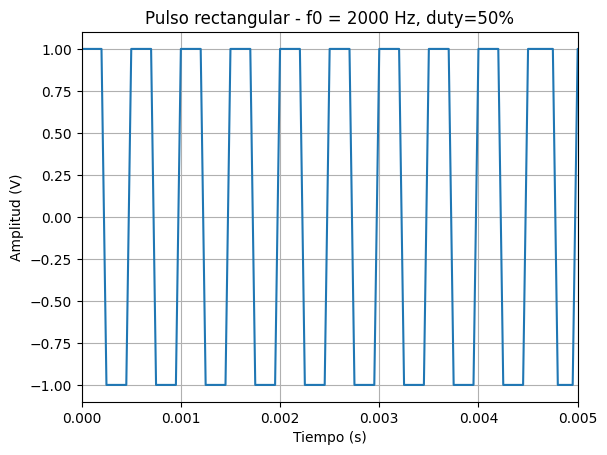

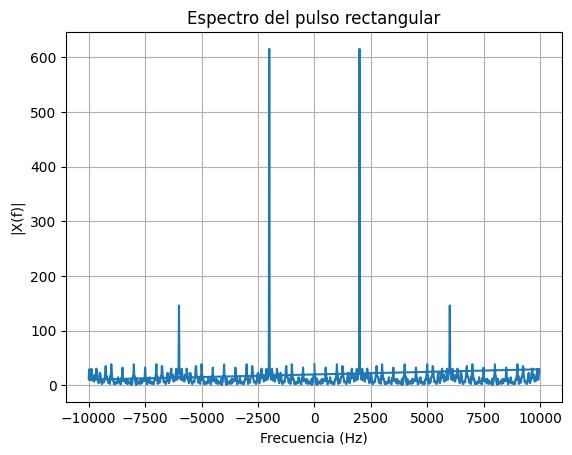

In [9]:
f0 = 2000
fs = 20000
n = 1000
ts = 1/fs
tt5 = np.linspace(0, (n-1)*ts, n)

P = 1  # potencia deseada
vmax = np.sqrt(P)  # para señal cuadrada simétrica, P = vmax^2 siempre (no vmax^2/2 como en la senoidal)

xx5 = vmax * signal.square(2*np.pi*f0*tt5, duty=0.5)

plt.figure()
plt.title('Pulso rectangular - f0 = 2000 Hz, duty=50%')
plt.xlim(0, 0.005)  # mismos 10 ciclos que en las señales anteriores
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt5, xx5)

XX5 = np.fft.fft(xx5)
ff5 = np.fft.fftfreq(n, d=ts)

plt.figure()
plt.title('Espectro del pulso rectangular')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.plot(ff5, np.abs(XX5))

In [10]:
from IPython.display import IFrame
IFrame("TS1_entrega.pdf", width=800, height=600)
